In [16]:
import pandas as pd 
import statsmodels.api as sm

insurance = "insurance.csv"
insurance = pd.read_csv(insurance)
dummies = pd.get_dummies(insurance[['sex','smoker']], dtype=int )
insurance = pd.concat([insurance, dummies], axis= 1)
insurance.head()


,age,sex,bmi,children,smoker,region,charges,sex_female,sex_male,smoker_no,smoker_yes
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0,1
1,18,male,33.770,1,no,southeast,1725.55230,0,1,1,0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,1,0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,1,0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,1,0


Intercept: -5571.083408548651
Coefficients: [223.79653146 330.79448868]
Mean Absolute Error (MAE): 9222.664535238679
Mean Squared Error (MSE): 131440262.76073726
Root Mean Squared Error (RMSE): 11464.739977894713
R-squared (R²): 0.1533569292467798


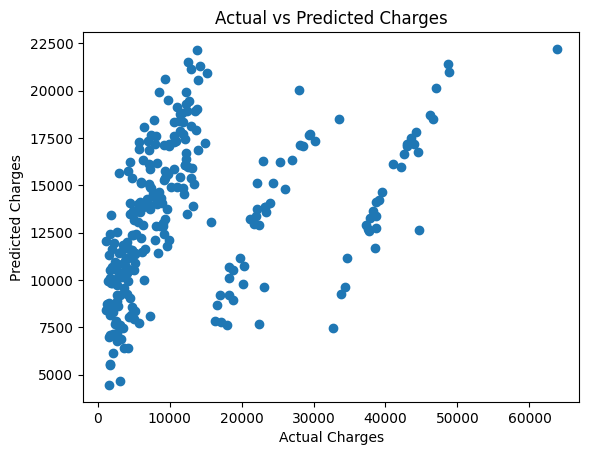

NameError: name 'df' is not defined

In [ ]:
from sklearn.preprocessing import StandardScaler 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_s = insurance.copy()
df_s[['age','bmi']] = StandardScaler().fit_transform(df_s[['age', 'bmi']])

X = insurance[['age', 'bmi']]  # Independent variables
y = insurance['charges']  # Dependent variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Print model coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Evaluate model performance
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared (R²):", r2_score(y_test, y_pred))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()



In [17]:
import statsmodels.formula.api as smf  
model = smf.ols('sex + smoker', data= insurance).fit()
print(model.summary())

PatsyError: model is missing required outcome variables

In [ ]:
import statsmodels.api as sm
# Convert categorical variables into dummy variables
insurance[['sex', 'smoker']] = pd.get_dummies(insurance[['sex', 'smoker']], drop_first=True)

# Rename the columns for clarity
insurance.rename(columns={'sex': 'male', 'smoker': 'smoker_yes'}, inplace=True)

X1 = insurance[['male']]  # Independent variable
X1 = sm.add_constant(X1)  # Add intercept
y = insurance['charges']  # Dependent variable

model1 = sm.OLS(y, X1).fit()
print(model1.summary())




TypeError: string indices must be integers, not 'list'